In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import joblib
import random as rn

In [2]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
rn.seed(RANDOM_SEED)

In [3]:
BATCH_SIZE = 256
LATENT_DIM = 4

In [4]:
patients = {
    1: ['Data/organized_fcs_data1a.csv', 'Data/organized_fcs_data1b.csv', 'Data/organized_fcs_data1c.csv'],
    2: ['Data/organized_fcs_data2a.csv', 'Data/organized_fcs_data2b.csv', 'Data/organized_fcs_data2c.csv'],
    3: ['Data/organized_fcs_data3a.csv', 'Data/organized_fcs_data3b.csv', 'Data/organized_fcs_data3c.csv'],
    4: ['Data/organized_fcs_data4a.csv', 'Data/organized_fcs_data4b.csv', 'Data/organized_fcs_data4c.csv'],
    5: ['Data/organized_fcs_data5a.csv', 'Data/organized_fcs_data5b.csv', 'Data/organized_fcs_data5c.csv'],
    6: ['Data/organized_fcs_data6a.csv', 'Data/organized_fcs_data6b.csv', 'Data/organized_fcs_data6c.csv'],
    7: ['Data/organized_fcs_data7.csv'],
    8: ['Data/organized_fcs_data8a.csv', 'Data/organized_fcs_data8b.csv', 'Data/organized_fcs_data8c.csv'],
    9: ['Data/organized_fcs_data9a.csv', 'Data/organized_fcs_data9b.csv'],
    10: ['Data/organized_fcs_data10a.csv', 'Data/organized_fcs_data10b.csv', 'Data/organized_fcs_data10c.csv'],
    11: ['Data/organized_fcs_data11.csv'],
    12: ['Data/organized_fcs_data12a.csv', 'Data/organized_fcs_data12b.csv', 'Data/organized_fcs_data12c.csv']
}

In [ ]:
training_ids = [1, 2, 3, 4, 5, 6]
test_ids = [7, 8, 9, 10, 11, 12]

In [ ]:
def load_and_concatenate(ids):
    all_data = []
    for pid in ids:
        dfs = [pd.read_csv(fp).drop(columns=['Time'], errors='ignore') for fp in patients[pid]]
        all_data.append(pd.concat(dfs))
    return pd.concat(all_data, ignore_index=True)

In [7]:
train_df = load_and_concatenate(training_ids)
test_df = load_and_concatenate(test_ids)

In [8]:
pipeline = Pipeline([('scaler', MinMaxScaler())])
pipeline.fit(train_df)
X_train = pipeline.transform(train_df)
X_test = pipeline.transform(test_df)

In [9]:
class CustomDataset(Dataset):
    def __init__(self,dataset):
        self.dataset = torch.tensor(dataset, dtype=torch.float32)
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        return self.dataset[idx]

In [10]:
train_loader = DataLoader(CustomDataset(X_train), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CustomDataset(X_test), batch_size=BATCH_SIZE, shuffle=False)

In [11]:
input_dim = X_train.shape[1]

In [20]:
class VarAutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ELU(),
            nn.Linear(16, 8),
            nn.ELU(),
            nn.Linear(8, 4),
            nn.ELU(),
        )

        self.fc_mu = nn.Linear(4, latent_dim)
        self.fc_log_var = nn.Linear(4, latent_dim)

        # Decoder layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 4),
            nn.ELU(),
            nn.Linear(4, 8),
            nn.ELU(),
            nn.Linear(8, 16),
            nn.ELU(),
            nn.Linear(16, input_dim),
            nn.ELU()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        log_var = self.fc_log_var(encoded)
        z = self.reparameterize(mu, log_var)
        decoded = self.decoder(z)
        return decoded, mu, log_var

In [21]:
vae = VarAutoEncoder(input_dim=input_dim, latent_dim=LATENT_DIM)
vae.load_state_dict(torch.load("vae_4dim_6_final.pth"))
vae.eval()

VarAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=16, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=4, bias=True)
    (5): ELU(alpha=1.0)
  )
  (fc_mu): Linear(in_features=4, out_features=4, bias=True)
  (fc_log_var): Linear(in_features=4, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=4, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=4, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=16, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=16, out_features=14, bias=True)
    (7): ELU(alpha=1.0)
  )
)

In [22]:
#latent space extraction 
def extract_latent(model, loader):
    latents = []
    model.eval()
    with torch.no_grad():
        for x in loader:
            enc = model.encoder(x)
            mu = model.fc_mu(enc)
            latents.append(mu.numpy())
    return np.vstack(latents)

In [23]:
latent_train = extract_latent(vae, train_loader)
latent_test = extract_latent(vae, test_loader)

In [24]:
print(f"Train latent shape: {latent_train.shape}")
print(f"Test latent shape: {latent_test.shape}")

Train latent shape: (27206732, 4)
Test latent shape: (20669340, 4)


In [ ]:
# gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
# gmm.fit(latent_train)
# joblib.dump(gmm, 'vg1.pkl')

gmm = joblib.load('VM_4Comp.pkl')

In [26]:
labels_train = gmm.predict(latent_train)
labels_test = gmm.predict(latent_test)

In [27]:
all_latent = np.vstack([latent_train, latent_test])
all_labels = np.concatenate([labels_train, labels_test])

In [30]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(all_latent)

In [31]:
latent_train_2d = latent_2d[:len(latent_train)]
latent_test_2d = latent_2d[len(latent_train):]

/var/folders/bd/9ft36zdj2zj1l_tnnp4gt6_80000gn/T/ipykernel_5944/4272668789.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/theaayush/Desktop/VAE + GMM/dl_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


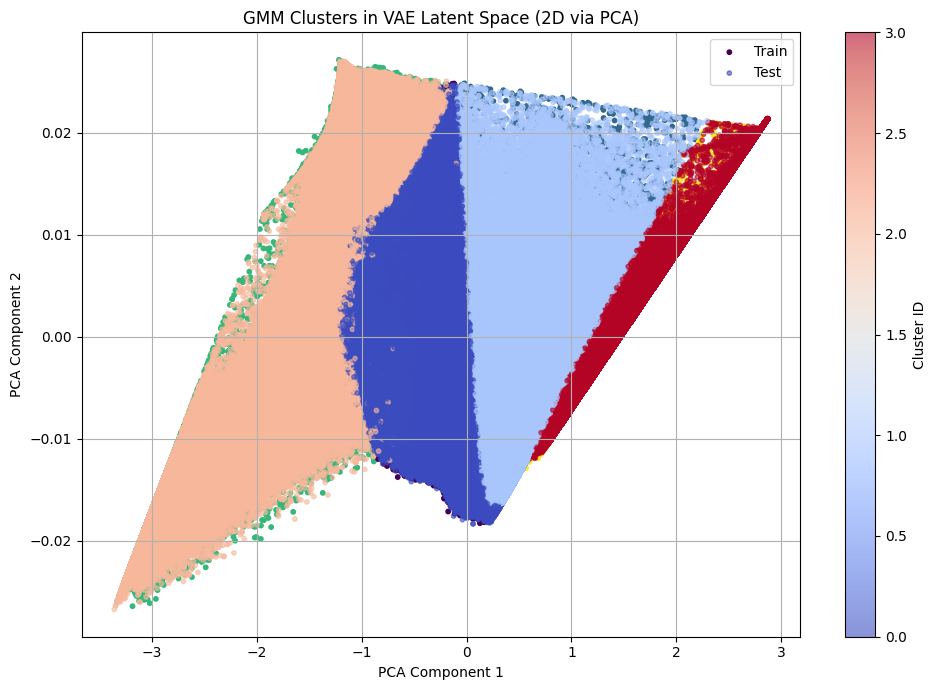

In [32]:
plt.figure(figsize=(10, 7))
plt.scatter(latent_train_2d[:, 0], latent_train_2d[:, 1], c=labels_train, cmap='viridis', s=10, label="Train")
plt.scatter(latent_test_2d[:, 0], latent_test_2d[:, 1], c=labels_test, cmap='coolwarm', s=10, label="Test", alpha=0.6)
plt.title("GMM Clusters in VAE Latent Space (2D via PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.colorbar(label="Cluster ID")
plt.tight_layout()
plt.show()

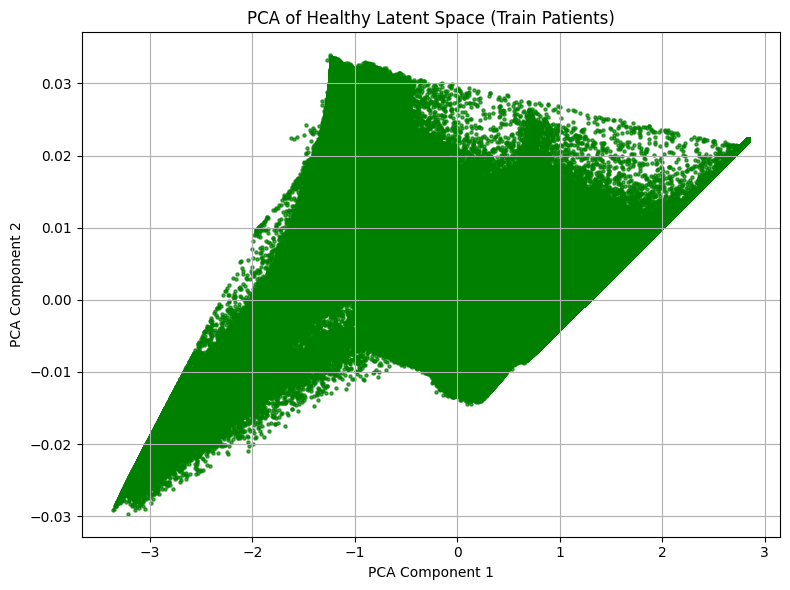

In [33]:
pca_healthy = PCA(n_components=2)
latent_healthy_2d = pca_healthy.fit_transform(latent_train)

plt.figure(figsize=(8, 6))
plt.scatter(latent_healthy_2d[:, 0], latent_healthy_2d[:, 1], s=5, alpha=0.7, color='green')
plt.title("PCA of Healthy Latent Space (Train Patients)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

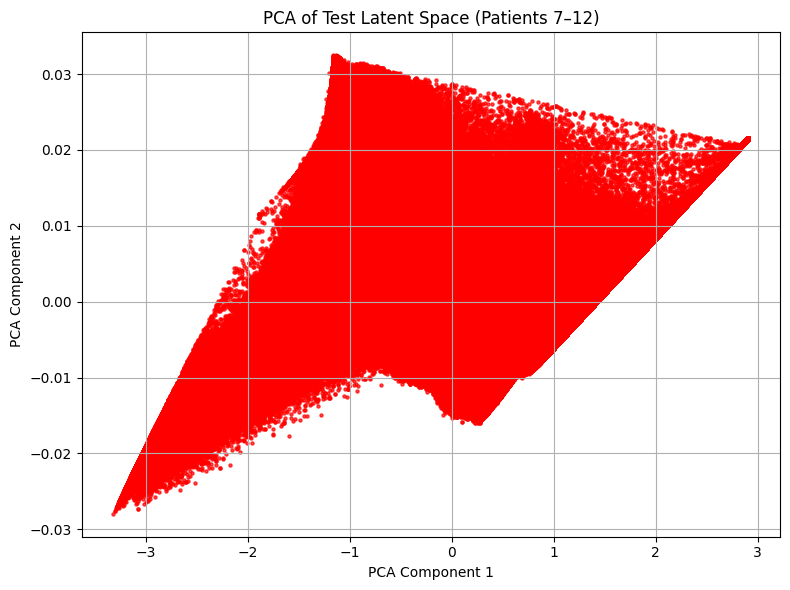

In [34]:
pca_unhealthy = PCA(n_components=2)
latent_unhealthy_2d = pca_unhealthy.fit_transform(latent_test)

plt.figure(figsize=(8, 6))
plt.scatter(latent_unhealthy_2d[:, 0], latent_unhealthy_2d[:, 1], s=5, alpha=0.7, color='red')
plt.title("PCA of Test Latent Space (Patients 7–12)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/bd/9ft36zdj2zj1l_tnnp4gt6_80000gn/T/ipykernel_5944/1909522367.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/theaayush/Desktop/VAE + GMM/dl_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


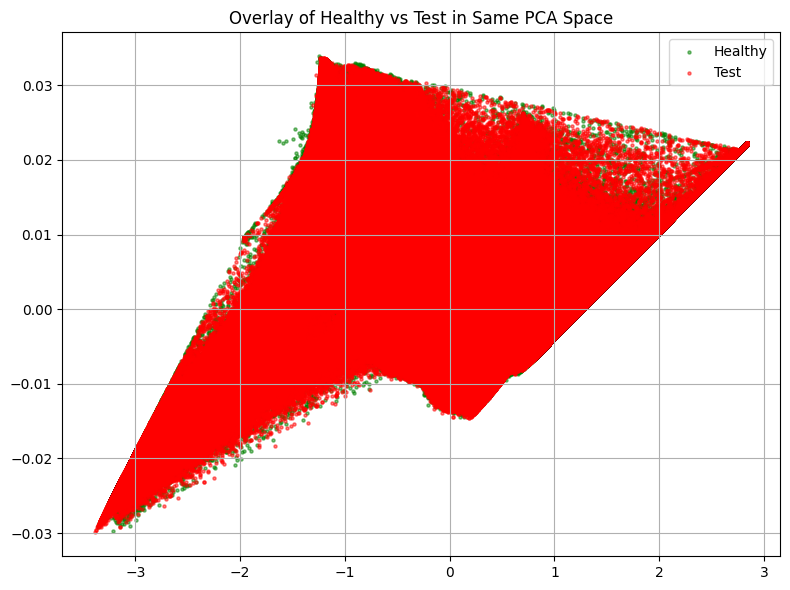

In [37]:
pca = PCA(n_components=2)
pca.fit(latent_train)

latent_healthy_2d = pca.transform(latent_train)
latent_test_2d = pca.transform(latent_test)

plt.figure(figsize=(8,6))
plt.scatter(latent_healthy_2d[:, 0], latent_healthy_2d[:, 1], s=5, alpha=0.5, label='Healthy', color='green')
plt.scatter(latent_test_2d[:, 0], latent_test_2d[:, 1], s=5, alpha=0.5, label='Test', color='red')
plt.legend()
plt.title("Overlay of Healthy vs Test in Same PCA Space")
plt.grid(True)
plt.tight_layout()
plt.show()
